In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.io.arff import loadarff

sns.set_theme(style="whitegrid")
df = pd.DataFrame(loadarff("people_data.arff")[0])

df.info()
pd.set_option("display.max_colwidth", None)
for col in df.select_dtypes("object").columns:
    df[col] = df[col].str.decode("utf-8").replace("?", np.nan)

missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  float64
 1   workclass       48842 non-null  object 
 2   fnlwgt          48842 non-null  float64
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  float64
 5   marital-status  48842 non-null  object 
 6   occupation      48842 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  float64
 11  capital-loss    48842 non-null  float64
 12  hours-per-week  48842 non-null  float64
 13  native-country  48842 non-null  object 
 14  class           48842 non-null  object 
dtypes: float64(6), object(9)
memory usage: 5.6+ MB


occupation        2809
workclass         2799
native-country     857
dtype: int64

count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64
skew: 0.5575803166133181


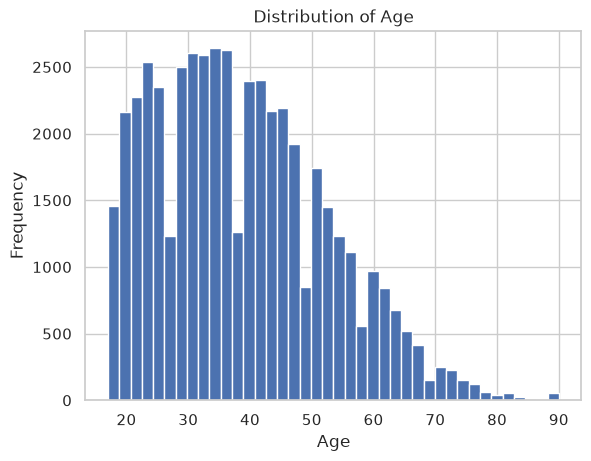

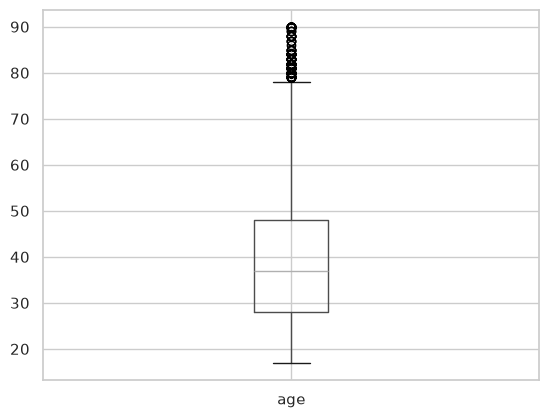

In [21]:
print(df["age"].describe())
print("skew:", df["age"].skew())

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
df["age"].hist(bins=40)
plt.show()

df.boxplot(column="age")
plt.show()

count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64
skew: 0.2387496572027575
hours-per-week
40.0    22803
50.0     4246
45.0     2717
60.0     2177
35.0     1937
20.0     1862
30.0     1700
55.0     1051
25.0      958
48.0      770
Name: count, dtype: int64


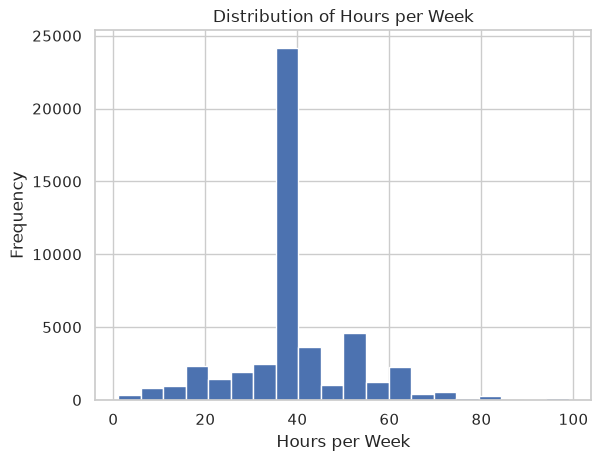

In [3]:
print(df["hours-per-week"].describe())
print("skew:", df["hours-per-week"].skew())
print(df["hours-per-week"].value_counts().head(10))

plt.title("Distribution of Hours per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Frequency")
df["hours-per-week"].hist(bins=20)
plt.show()

education
Preschool        1.0
1st-4th          2.0
5th-6th          3.0
7th-8th          4.0
9th              5.0
10th             6.0
11th             7.0
12th             8.0
HS-grad          9.0
Some-college    10.0
Assoc-voc       11.0
Assoc-acdm      12.0
Bachelors       13.0
Masters         14.0
Prof-school     15.0
Doctorate       16.0
Name: education-num, dtype: float64


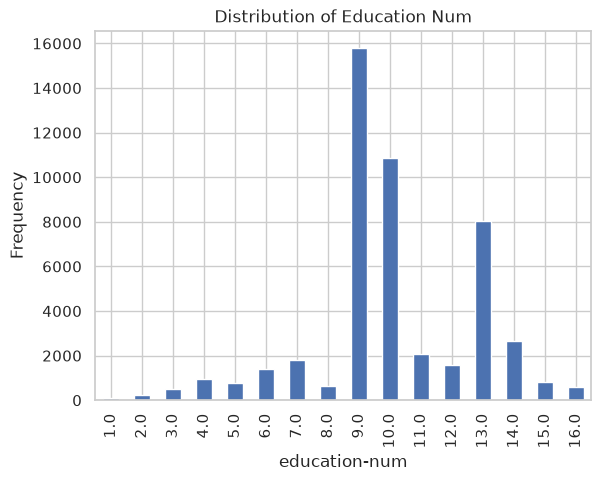

In [4]:
print(df.groupby("education")["education-num"].first().sort_values())

plt.title("Distribution of Education Num")
plt.xlabel("Education Num")
plt.ylabel("Frequency")
df["education-num"].value_counts().sort_index().plot(kind="bar")
plt.show()

In [5]:
for col in ["occupation", "workclass", "relationship", "marital-status", "race", "sex", "native-country"]:
    print(df[col].value_counts())
    print((df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + "%"))

    print("------------------------")

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64
occupation
Prof-specialty       13.41%
Craft-repair         13.28%
Exec-managerial      13.22%
Adm-clerical         12.19%
Sales                11.96%
Other-service        10.69%
Machine-op-inspct     6.56%
Transport-moving      5.12%
Handlers-cleaners      4.5%
Farming-fishing       3.24%
Tech-support          3.14%
Protective-serv       2.14%
Priv-house-serv       0.53%
Armed-Forces          0.03%
Name: proportion, dtype: str
------------------------
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Fe

In [6]:
print(df["class"].value_counts(normalize=True))
print((df["class"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%"))

class
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64
class
<=50K    76.07%
>50K     23.93%
Name: proportion, dtype: str


# Analysis
The biggest things worth noting are
- ages start at 17, but most are between 28-48
- the majority of the sample has graduated high school, some college, or a bachelors degree
- the majority of the sample has a 40 hour work week
- 73.6% of the sample work in the private sector
- 40% of the sample are husbands while only 5% are wives, but 67% of the sample are male and 33% are female. What is the correlation between being male and being married?
- 91% of the sample is from the US while the other 9% are from various other countries
- 76% of the sample make more than 50k per year, the other 24% make less than 50k per year

In [7]:
from apriori_from_scratch import apriori

items = df.drop(columns=["fnlwgt", "education-num"])

items["age"] = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, 100], right=False,
                      labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"])
items["hours-per-week"] = pd.cut(df["hours-per-week"], bins=[0, 35, 41, 100], right=False,
                                 labels=["part-time", "full-time", "overtime"])
items["capital-gain"] = np.where(df["capital-gain"] > 0, "yes", None)
items["capital-loss"] = np.where(df["capital-loss"] > 0, "yes", None)

transactions = [
    {f"{col}={val}" for col, val in row.items() if pd.notna(val)}
    for row in items.to_dict("records")
]
transactions[0]

{'age=25-34',
 'class=<=50K',
 'education=11th',
 'hours-per-week=full-time',
 'marital-status=Never-married',
 'native-country=United-States',
 'occupation=Machine-op-inspct',
 'race=Black',
 'relationship=Own-child',
 'sex=Male',
 'workclass=Private'}

In [8]:
rules = apriori(transactions, min_frequency=int(0.05 * len(transactions)))
rules = pd.DataFrame(rules, columns=["antecedent", "consequent", "support", "confidence", "lift"])
rules = rules[rules["consequent"].str.len() == 1]

print(len(rules))

10573


In [9]:
rules[(rules["confidence"] > 0.6) & (rules["lift"] > 1.5)].sort_values("lift", ascending=False).head(20)

,antecedent,consequent,support,confidence,lift
37166,"(class=<=50K, hours-per-week=part-time, marital-status=Never-married, native-country=United-States, relationship=Own-child)","(age=<25,)",0.050489,0.897380,5.198035
31184,"(hours-per-week=part-time, marital-status=Never-married, native-country=United-States, relationship=Own-child)","(age=<25,)",0.050551,0.897166,5.196794
18614,"(class=<=50K, hours-per-week=part-time, marital-status=Never-married, relationship=Own-child)","(age=<25,)",0.053294,0.896041,5.190281
8350,"(hours-per-week=part-time, marital-status=Never-married, relationship=Own-child)","(age=<25,)",0.053376,0.895876,5.189325
19005,"(class=<=50K, hours-per-week=part-time, native-country=United-States, relationship=Own-child)","(age=<25,)",0.051124,0.871249,5.046673
5158,"(hours-per-week=part-time, native-country=United-States, relationship=Own-child)","(age=<25,)",0.051185,0.870171,5.040426
13604,"(class=<=50K, hours-per-week=part-time, relationship=Own-child)","(age=<25,)",0.053990,0.869436,5.036172
3766,"(hours-per-week=part-time, relationship=Own-child)","(age=<25,)",0.054072,0.868179,5.028889
37152,"(age=<25, class=<=50K, hours-per-week=part-time, marital-status=Never-married, native-country=United-States)","(relationship=Own-child,)",0.050489,0.769663,4.958696
31185,"(age=<25, hours-per-week=part-time, marital-status=Never-married, native-country=United-States)","(relationship=Own-child,)",0.050551,0.769159,4.955449


In [10]:
print(rules[rules["consequent"] == ("class=>50K",)].sort_values("confidence", ascending=False).head(15))
print(rules[rules["consequent"] == ("class=<=50K",)].sort_values("confidence", ascending=False).head(15))

                                                                                       antecedent  \
11045      (education=Bachelors, marital-status=Married-civ-spouse, native-country=United-States)   
3073                              (marital-status=Married-civ-spouse, occupation=Exec-managerial)   
11017                        (education=Bachelors, marital-status=Married-civ-spouse, race=White)   
2635                                                  (education=Bachelors, relationship=Husband)   
10359                                       (education=Bachelors, relationship=Husband, sex=Male)   
24825    (education=Bachelors, marital-status=Married-civ-spouse, relationship=Husband, sex=Male)   
9589               (education=Bachelors, marital-status=Married-civ-spouse, relationship=Husband)   
13397                          (education=Bachelors, marital-status=Married-civ-spouse, sex=Male)   
3145                                     (education=Bachelors, marital-status=Married-civ-s

# Apriori Analysis
The apriori reveals that in this sample, the people who are most likely to make more than 50k per year are
  - College grads who are married and from the US
  - Married execs
  - Married Males with college degrees
  - White married males aged 45-54

Those who are most likely to make less than 50k per year are
  - part time, never-married individuals less than 25

In [11]:
df["high_income"] = (df["class"] == ">50K").astype(int)

              count      mean
education                    
10th           1389  0.062635
11th           1812  0.050773
12th            657  0.073059
1st-4th         247  0.032389
5th-6th         509  0.053045
7th-8th         955  0.064921
9th             756  0.054233
Assoc-acdm     1601  0.257964
Assoc-voc      2061  0.253275
Bachelors      8025  0.412835
Doctorate       594  0.725589
HS-grad       15784  0.158578
Masters        2657  0.549116
Preschool        83  0.012048
Prof-school     834  0.739808
Some-college  10878  0.189649


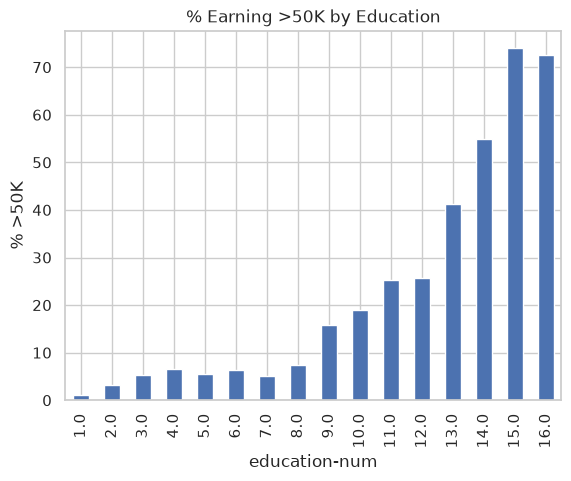

In [24]:
print(df.groupby("education")["high_income"].agg(["count", "mean"]))

plt.title("% Earning >50K by Education")
plt.xlabel("Education")
plt.ylabel("% >50K")
df.groupby("education-num")["high_income"].mean().mul(100).plot(kind="bar")
plt.show()

## Education Factor
The people in this sample with more education have a higher likelihood that they make more than 50k per year.

class                  <=50K  >50K
marital-status                    
Divorced                89.9  10.1
Married-AF-spouse       62.2  37.8
Married-civ-spouse      55.4  44.6
Married-spouse-absent   90.8   9.2
Never-married           95.5   4.5
Separated               93.5   6.5
Widowed                 91.6   8.4


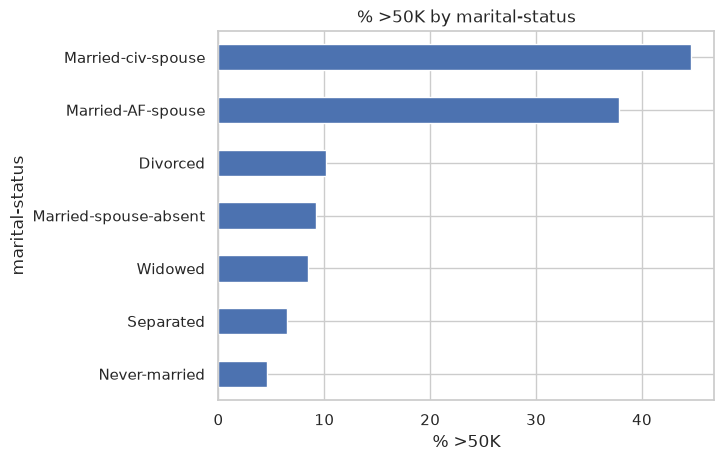

class           <=50K  >50K
relationship               
Husband          55.1  44.9
Not-in-family    89.9  10.1
Other-relative   96.5   3.5
Own-child        98.5   1.5
Unmarried        94.0   6.0
Wife             53.1  46.9


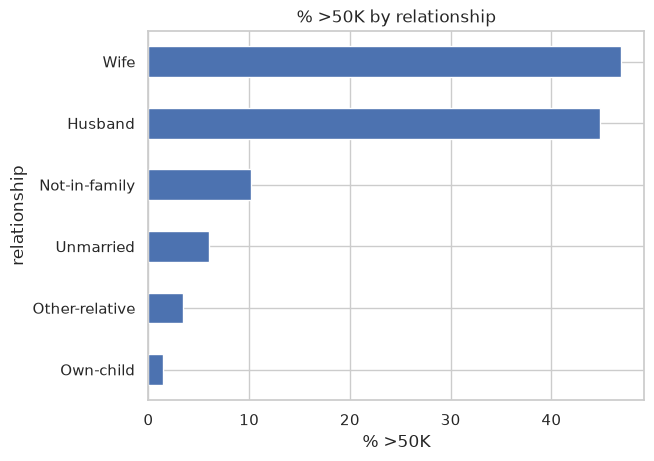

In [13]:
for col in ["marital-status", "relationship"]:
    print(pd.crosstab(df[col], df["class"], normalize="index").mul(100).round(1))
    df.groupby(col)["high_income"].mean().mul(100).sort_values().plot(kind="barh")
    plt.title(f"% >50K by {col}")
    plt.xlabel("% >50K")
    plt.show()

In [ ]:
print(pd.crosstab(df["relationship"], df["sex"]))
print(pd.crosstab(df["sex"], df["class"], normalize="index").mul(100).round(1))

sex             Female   Male
relationship                 
Husband              1  19715
Not-in-family     5870   6713
Other-relative     689    817
Own-child         3376   4205
Unmarried         3928   1197
Wife              2328      3
class   <=50K  >50K
sex                
Female   89.1  10.9
Male     69.6  30.4


In [22]:
married = df["marital-status"].str.startswith("Married")
print(married.groupby(df["sex"]).mean().mul(100).round(1))

sex
Female    17.3
Male      62.0
Name: marital-status, dtype: float64


# Analysis of Marriage VS Income
It's worth noticing that 62% of males sampled are married while only 17.3% of females sampled are married.
The data of this sample shows that there is likely some correlation between being married and making more money. People who are married in this sample have a higher percentage of making more than 50k than single people.

         count       mean        std   min   25%   50%   75%   max
class                                                             
<=50K  37155.0  36.872184  14.104118  17.0  25.0  34.0  46.0  90.0
>50K   11687.0  44.275178  10.558983  19.0  36.0  43.0  51.0  90.0


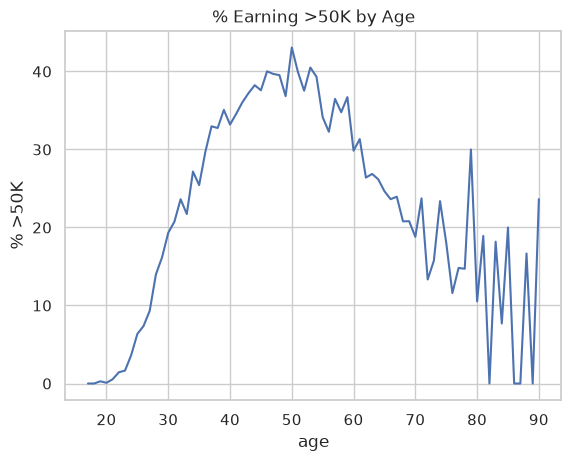

In [27]:
print(df.groupby("class")["age"].describe())

plt.title("% Earning >50K by Age")
plt.xlabel("Age")
plt.ylabel("% >50K")
df.groupby("age")["high_income"].mean().mul(100).plot()
plt.show()

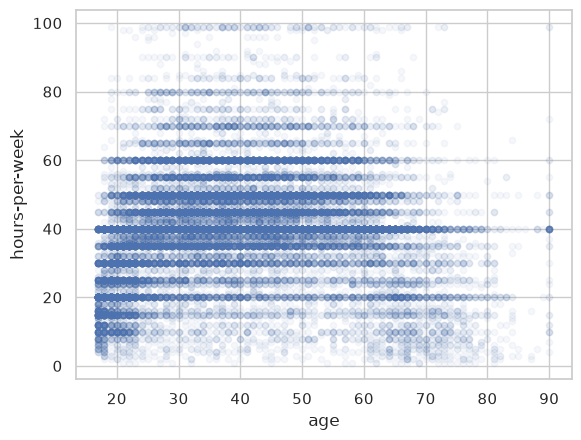

0.07155833852698291


age
[0, 25)      38.0
[25, 35)     40.0
[35, 45)     40.0
[45, 55)     40.0
[55, 65)     40.0
[65, 100)    30.0
Name: hours-per-week, dtype: float64

In [28]:
df.plot.scatter(x="age", y="hours-per-week", alpha=0.05)
plt.show()

print(df["age"].corr(df["hours-per-week"]))
df.groupby(pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, 100], right=False))["hours-per-week"].median()

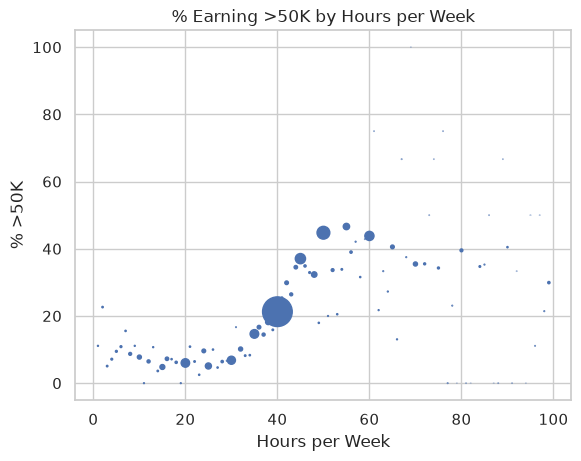

In [31]:
by_hour = df.groupby("hours-per-week")["high_income"].agg(["count", "mean"])
plt.scatter(by_hour.index, by_hour["mean"] * 100, s=by_hour["count"] / 50)
plt.title("% Earning >50K by Hours per Week")
plt.xlabel("Hours per Week")
plt.ylabel("% >50K")
plt.show()

# Age and Hours Impact on Income
The above charts show that as people go from age 20-50 in this sample, the likelihood of making 50k or more increases, and then at 50, as the age of those sampled increases, the likelihood that they make 50k per year decreases.

This same trend of a bellcurve like shape can be seen in the chart that shows the relationship of age and hours worked in a week. 40-50 is the peak where the most people work the most above 40 hours, and it decreases as age increases after about 50.

The final chart shows that 50 or so hours in a work week is the # of hours with the highest percentage of greater than 50k per year.

                   count      mean
occupation                        
Priv-house-serv      242  0.012397
Other-service       4923  0.041438
Handlers-cleaners   2072  0.066602
Farming-fishing     1490  0.116107
Machine-op-inspct   3022  0.123097
Adm-clerical        5611  0.136874
Transport-moving    2355  0.204246
Craft-repair        6112  0.226276
Sales               5504  0.267987
Tech-support        1446  0.290456
Protective-serv      983  0.313327
Armed-Forces          15  0.333333
Prof-specialty      6172  0.451069
Exec-managerial     6086  0.477818


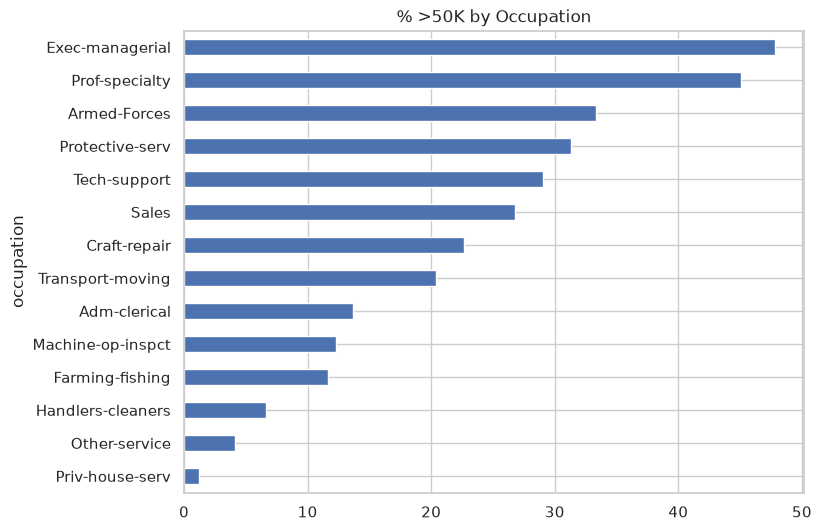

In [32]:
occ = df.groupby("occupation")["high_income"].agg(["count", "mean"]).sort_values("mean")
print(occ)

occ["mean"].mul(100).plot(kind="barh", figsize=(8, 6))
plt.title("% >50K by Occupation")
plt.show()

# Occupation vs income
This shows that in this sample, executives and those with certain specialty skills are the ones most likely to make more than 50k per year.